<a href="https://colab.research.google.com/github/ryankennedy5103/BTE320/blob/main/Pairs_Trading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install yfinance statsmodels matplotlib pandas numpy -q
print("✓ Done!")

✓ Done!


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import yfinance as yf

%matplotlib inline
print("✓ Libraries loaded!")

✓ Libraries loaded!


In [17]:
# ── CHANGE THESE TO ANY TWO STOCKS YOU WANT ──
TICKER_1   = 'GS'           # First stock
TICKER_2   = 'MS'          # Second stock
START_DATE = '2012-01-01'
END_DATE   = '2025-12-31'
FREQUENCY  = 'M'            # M = monthly, D = daily
Z_ENTRY    = 2.0            # Open trade at this z-score
Z_EXIT     = 0.5            # Close trade at this z-score
# ─────────────────────────────────────────────

print(f"✓ Settings saved: {TICKER_1} vs {TICKER_2}")


✓ Settings saved: GS vs MS


In [18]:
print(f'Downloading data for {TICKER_1} and {TICKER_2}...')

raw   = yf.download([TICKER_1, TICKER_2], start=START_DATE, end=END_DATE,
                    auto_adjust=True, progress=False)
close = raw['Close'][[TICKER_1, TICKER_2]].dropna()

if FREQUENCY == 'M':
    close = close.resample('ME').last()

print(f'✓ Downloaded {len(close)} observations.')
close.head()

✓ Downloaded 168 observations.


Ticker,GS,MS
Date,,
2012-01-31,85.475655,13.370332
2012-02-29,88.556465,13.291471
2012-03-31,95.655472,14.080071
2012-04-30,88.564171,12.424408
2012-05-31,73.956619,9.605911


In [19]:
Y = close[TICKER_1]
X = sm.add_constant(close[TICKER_2])
model = sm.OLS(Y, X).fit()

ALPHA = model.params['const']
BETA  = model.params[TICKER_2]
R2    = model.rsquared

print('=' * 55)
print('REGRESSION RESULTS')
print('=' * 55)
print(f'  Equation : {TICKER_1} = {ALPHA:.4f} + {BETA:.4f} × {TICKER_2}')
print(f'  R²       : {R2:.4f}  →  {TICKER_2} explains {R2*100:.1f}% of {TICKER_1}\'s movement')
print(f'  Alpha    : {ALPHA:.4f}')
print(f'  Beta     : {BETA:.4f}')
print('=' * 55)

REGRESSION RESULTS
  Equation : GS = 23.1383 + 4.3160 × MS
  R²       : 0.9645  →  MS explains 96.4% of GS's movement
  Alpha    : 23.1383
  Beta     : 4.3160


In [20]:
fitted    = ALPHA + BETA * close[TICKER_2]
residuals = close[TICKER_1] - fitted

spread_df = pd.DataFrame({
    f'{TICKER_1}_Close'  : close[TICKER_1],
    f'{TICKER_2}_Close'  : close[TICKER_2],
    'Fitted'             : fitted,
    'Residual'           : residuals,
    'Lagged_Residual'    : residuals.shift(1),
    'Change_in_Residual' : residuals.diff(),
})

print(f'Spread mean : {residuals.mean():.4f}')
print(f'Spread std  : {residuals.std():.4f}')
spread_df.head(10)


Spread mean : -0.0000
Spread std  : 30.6429


,GS_Close,MS_Close,Fitted,Residual,Lagged_Residual,Change_in_Residual
Date,,,,,,
2012-01-31,85.475655,13.370332,80.844844,4.630810,NaN,NaN
2012-02-29,88.556465,13.291471,80.504482,8.051983,4.630810,3.421173
2012-03-31,95.655472,14.080071,83.908092,11.747379,8.051983,3.695396
2012-04-30,88.564171,12.424408,76.762222,11.801949,11.747379,0.054570
2012-05-31,73.956619,9.605911,64.597544,9.359076,11.801949,-2.442874
2012-06-30,74.080246,10.490285,68.414515,5.665731,9.359076,-3.693345
2012-07-31,77.975128,9.859532,65.692176,12.282952,5.665731,6.617221
2012-08-31,82.059097,10.826719,69.866571,12.192526,12.282952,-0.090426
2012-09-30,88.237564,12.082620,75.287058,12.950506,12.192526,0.757980


In [21]:
adf_result = adfuller(residuals.dropna(), autolag='AIC')
adf_stat   = adf_result[0]
p_value    = adf_result[1]
crit       = adf_result[4]

print('=' * 55)
print('COINTEGRATION TEST')
print('=' * 55)
print(f'  ADF Statistic : {adf_stat:.4f}')
print(f'  P-value       : {p_value:.4f}')
print(f'  Critical values:')
for level, val in crit.items():
    print(f'      {level}: {val:.4f}')

if p_value < 0.05:
    IS_COINTEGRATED = True
    print(f'\n  ✓ COINTEGRATED — pairs trading is justified!')
else:
    IS_COINTEGRATED = False
    print(f'\n  ✗ NOT cointegrated at 5% — trade with caution.')
print('=' * 55)

COINTEGRATION TEST
  ADF Statistic : -1.4201
  P-value       : 0.5726
  Critical values:
      1%: -3.4701
      5%: -2.8790
      10%: -2.5761

  ✗ NOT cointegrated at 5% — trade with caution.


In [22]:
window    = min(60, len(residuals) // 2)
roll_mean = residuals.rolling(window).mean()
roll_std  = residuals.rolling(window).std()
z_score   = (residuals - roll_mean) / roll_std

signal   = pd.Series(0, index=z_score.index)
position = 0

for i in range(len(z_score)):
    z = z_score.iloc[i]
    if pd.isna(z):
        signal.iloc[i] = 0
        continue
    if position == 0:
        if z < -Z_ENTRY:
            position = 1
        elif z > Z_ENTRY:
            position = -1
    elif position == 1:
        if z > -Z_EXIT:
            position = 0
    elif position == -1:
        if z < Z_EXIT:
            position = 0
    signal.iloc[i] = position

spread_df['Z_Score'] = z_score
spread_df['Signal']  = signal

print(f'✓ Signals generated!')
print(f'  Periods long  : {(signal == 1).sum()}')
print(f'  Periods short : {(signal == -1).sum()}')
print(f'  Periods flat  : {(signal == 0).sum()}')

✓ Signals generated!
  Periods long  : 51
  Periods short : 22
  Periods flat  : 95


In [23]:
ret1 = close[TICKER_1].pct_change()
ret2 = close[TICKER_2].pct_change()

lagged_signal    = signal.shift(1).fillna(0)
strategy_returns = lagged_signal * (ret1 - ret2)
cumulative       = (1 + strategy_returns).cumprod()
buy_hold_1       = (1 + ret1).cumprod()
buy_hold_2       = (1 + ret2).cumprod()

total_return   = cumulative.iloc[-1] - 1
ann_return     = (1 + total_return) ** (12 / len(cumulative)) - 1
sharpe         = strategy_returns.mean() / strategy_returns.std() * np.sqrt(12)
max_dd         = (cumulative / cumulative.cummax() - 1).min()
active_returns = strategy_returns[strategy_returns != 0]
win_rate       = (active_returns > 0).mean() if len(active_returns) > 0 else 0

print('=' * 45)
print('BACKTEST RESULTS')
print('=' * 45)
print(f'  {"Total Return":<22} {total_return*100:>8.1f}%')
print(f'  {"Annualized Return":<22} {ann_return*100:>8.1f}%')
print(f'  {"Sharpe Ratio":<22} {sharpe:>9.2f}')
print(f'  {"Max Drawdown":<22} {max_dd*100:>8.1f}%')
print(f'  {"Win Rate":<22} {win_rate*100:>8.1f}%')
print('=' * 45)

BACKTEST RESULTS
  Total Return               27.1%
  Annualized Return           1.7%
  Sharpe Ratio                0.22
  Max Drawdown              -19.6%
  Win Rate                   52.1%


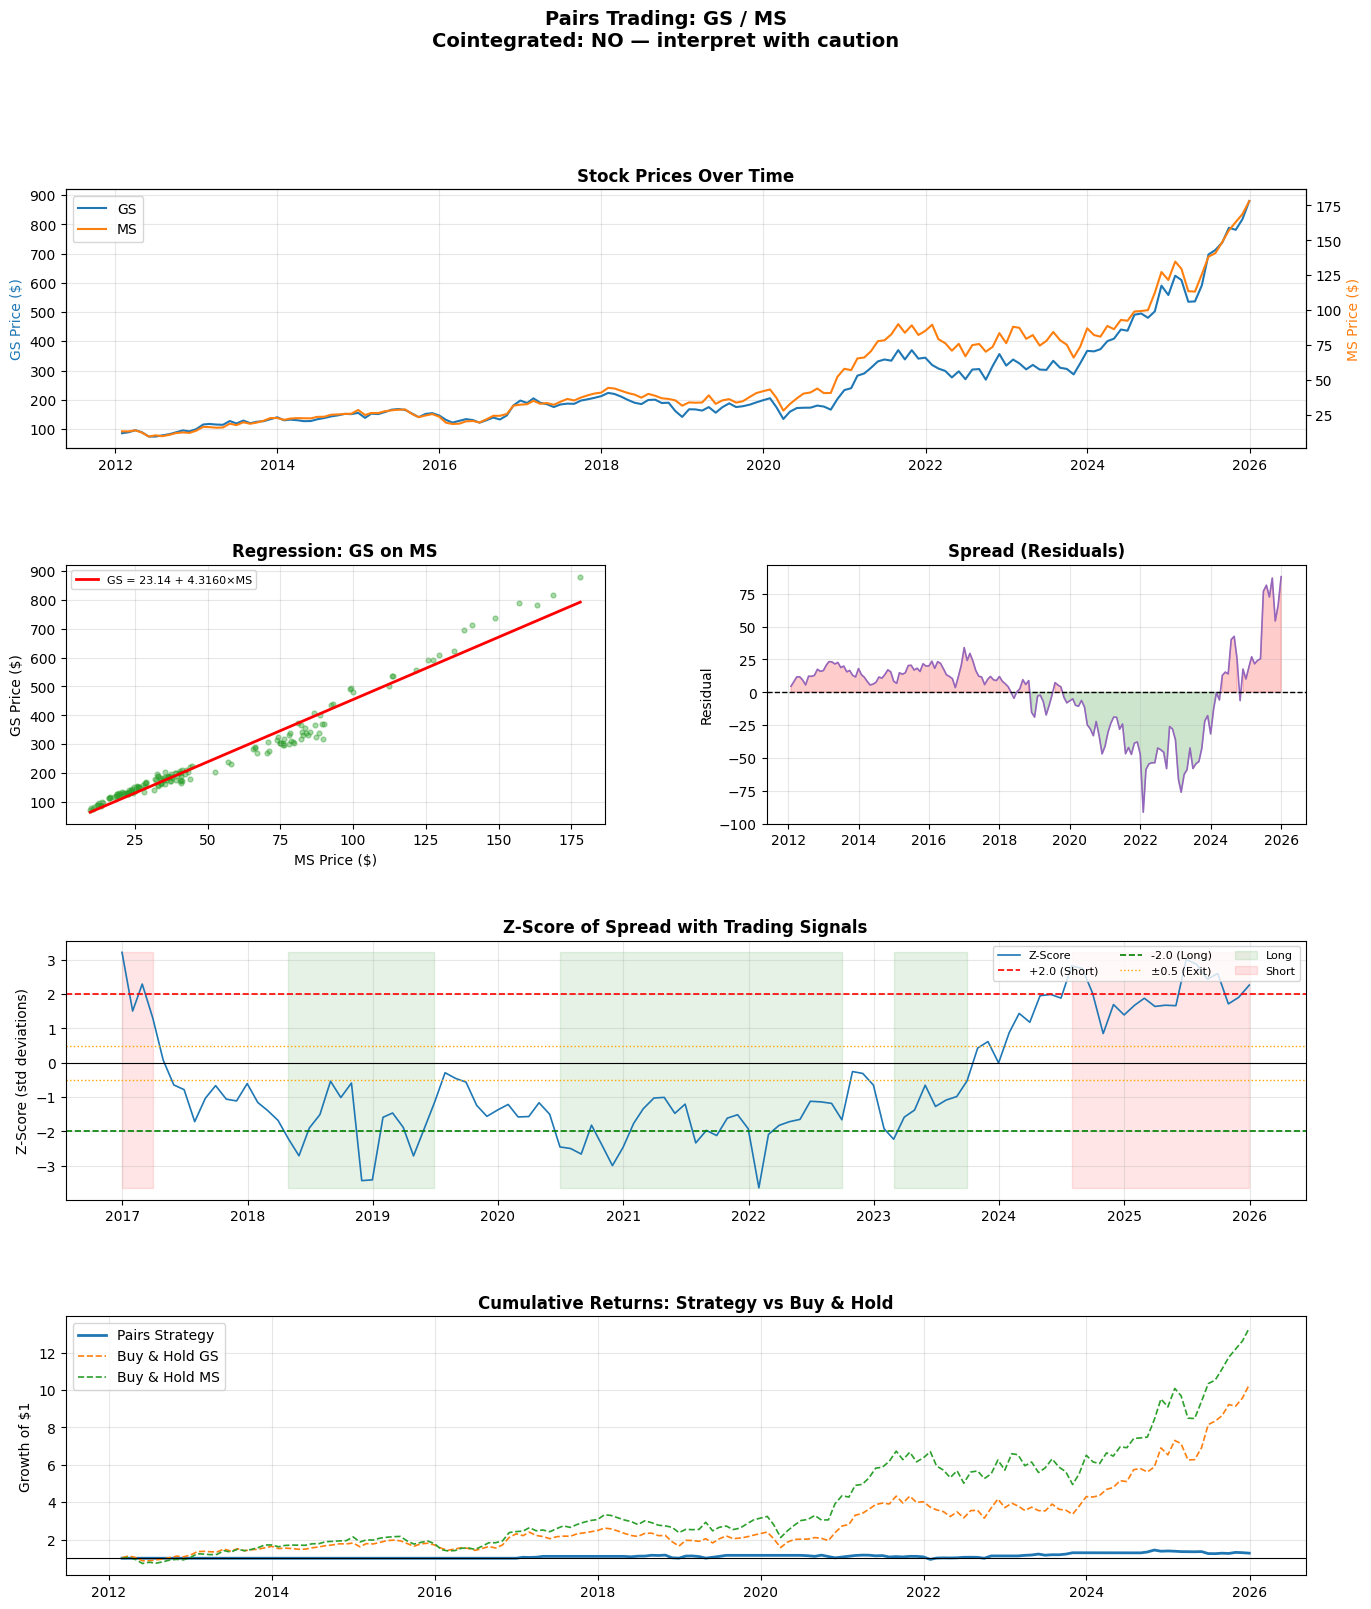

✓ Charts complete!


In [24]:
fig = plt.figure(figsize=(16, 18))
fig.suptitle(
    f'Pairs Trading: {TICKER_1} / {TICKER_2}\n'
    f'Cointegrated: {"YES ✓" if IS_COINTEGRATED else "NO — interpret with caution"}',
    fontsize=14, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.3)

ax1      = fig.add_subplot(gs[0, :])
ax1_twin = ax1.twinx()
ax1.plot(close.index, close[TICKER_1], color='#1f77b4', label=TICKER_1, linewidth=1.5)
ax1_twin.plot(close.index, close[TICKER_2], color='#ff7f0e', label=TICKER_2, linewidth=1.5)
ax1.set_title('Stock Prices Over Time', fontweight='bold')
ax1.set_ylabel(f'{TICKER_1} Price ($)', color='#1f77b4')
ax1_twin.set_ylabel(f'{TICKER_2} Price ($)', color='#ff7f0e')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(close[TICKER_2], close[TICKER_1], alpha=0.4, s=12, color='#2ca02c')
x_line = np.linspace(close[TICKER_2].min(), close[TICKER_2].max(), 100)
ax2.plot(x_line, ALPHA + BETA * x_line, color='red', linewidth=2,
         label=f'{TICKER_1} = {ALPHA:.2f} + {BETA:.4f}×{TICKER_2}')
ax2.set_xlabel(f'{TICKER_2} Price ($)')
ax2.set_ylabel(f'{TICKER_1} Price ($)')
ax2.set_title(f'Regression: {TICKER_1} on {TICKER_2}', fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(spread_df.index, spread_df['Residual'], color='#9467bd', linewidth=1.2)
ax3.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax3.fill_between(spread_df.index, spread_df['Residual'], 0,
                 where=spread_df['Residual']>0, alpha=0.2, color='red')
ax3.fill_between(spread_df.index, spread_df['Residual'], 0,
                 where=spread_df['Residual']<0, alpha=0.2, color='green')
ax3.set_title('Spread (Residuals)', fontweight='bold')
ax3.set_ylabel('Residual')
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[2, :])
ax4.plot(z_score.index, z_score, color='#1f77b4', linewidth=1.2, label='Z-Score')
ax4.axhline(y=0,        color='black',  linestyle='-',  linewidth=0.8)
ax4.axhline(y=Z_ENTRY,  color='red',    linestyle='--', linewidth=1.2, label=f'+{Z_ENTRY} (Short)')
ax4.axhline(y=-Z_ENTRY, color='green',  linestyle='--', linewidth=1.2, label=f'-{Z_ENTRY} (Long)')
ax4.axhline(y=Z_EXIT,   color='orange', linestyle=':',  linewidth=1,   label=f'±{Z_EXIT} (Exit)')
ax4.axhline(y=-Z_EXIT,  color='orange', linestyle=':',  linewidth=1)
ax4.fill_between(z_score.index, z_score.min(), z_score.max(),
                 where=signal==1,  alpha=0.1, color='green', label='Long')
ax4.fill_between(z_score.index, z_score.min(), z_score.max(),
                 where=signal==-1, alpha=0.1, color='red',   label='Short')
ax4.set_title('Z-Score of Spread with Trading Signals', fontweight='bold')
ax4.set_ylabel('Z-Score (std deviations)')
ax4.legend(loc='upper right', fontsize=8, ncol=3)
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[3, :])
ax5.plot(cumulative.index, cumulative,  color='#1f77b4', linewidth=2,   label='Pairs Strategy')
ax5.plot(buy_hold_1.index, buy_hold_1,  color='#ff7f0e', linewidth=1.2, linestyle='--', label=f'Buy & Hold {TICKER_1}')
ax5.plot(buy_hold_2.index, buy_hold_2,  color='#2ca02c', linewidth=1.2, linestyle='--', label=f'Buy & Hold {TICKER_2}')
ax5.axhline(y=1, color='black', linestyle='-', linewidth=0.8)
ax5.set_title('Cumulative Returns: Strategy vs Buy & Hold', fontweight='bold')
ax5.set_ylabel('Growth of $1')
ax5.legend(loc='upper left')
ax5.grid(True, alpha=0.3)

plt.show()
print('✓ Charts complete!')